<a href="https://colab.research.google.com/github/Egyy24/Klasifikasi-Spesies-Iris/blob/main/KlasifikasiSpesiesIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Qanzul Arays `23523228`


> Muhammad Ibnu Rasyid `23523127`








## Memuat Dataset
Memuat dataset `Iris.csv` menggunakan pandas, memeriksa informasi dasar, dan mengkodekan kolom target 'Species'.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Muat dataset
df_iris = pd.read_csv('/content/sample_data/Iris.csv')

# Tampilkan 5 baris pertama
print("5 baris pertama dataset Iris:")
display(df_iris.head())

# Periksa informasi dataset
print("\nInformasi dataset:")
df_iris.info()

# Periksa nilai yang hilang
print("\nJumlah nilai yang hilang per kolom:")
print(df_iris.isnull().sum())

# Pisahkan fitur (X) dan target (y)
X = df_iris.drop('Species', axis=1)
y = df_iris['Species']

# Mengkodekan label target menjadi angka
# LabelEncoder mengubah 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica' jadi 0, 1, 2
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Tampilkan pemetaan label
print("\nPemetaan label target:")
for i, species in enumerate(le.classes_):
    print(f"{species}: {i}")

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"\nUkuran data latih (X_train): {X_train.shape}")
print(f"Ukuran data uji (X_test): {X_test.shape}")

5 baris pertama dataset Iris:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Jumlah nilai yang hilang per kolom:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Pemetaan label target:
Iris-setosa: 0
Iris-versicolor: 1
Iris-virginica: 2

Ukuran data latih (X_train): (105, 5)
Ukuran data uji (X_test): (45, 5)


## Klasifikasi menggunakan Decision Tree
Melatih model Decision Tree, membuat prediksi, dan mengevaluasi kinerjanya menggunakan Akurasi, Confusion Matrix, dan Classification Report.

Akurasi Decision Tree: 1.0000

Confusion Matrix (Decision Tree):


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,19,0,0
Iris-versicolor,0,13,0
Iris-virginica,0,0,13



Classification Report (Decision Tree):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



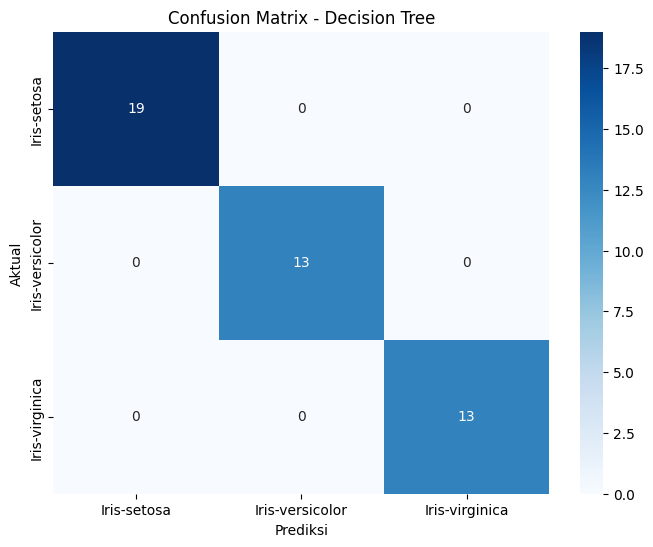

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi dan latih model Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_dtc = dtc.predict(X_test)

# Evaluasi model Decision Tree
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
cr_dtc = classification_report(y_test, y_pred_dtc, target_names=le.classes_)

print(f"Akurasi Decision Tree: {accuracy_dtc:.4f}")
print("\nConfusion Matrix (Decision Tree):")
display(pd.DataFrame(cm_dtc, index=le.classes_, columns=le.classes_))

print("\nClassification Report (Decision Tree):")
print(cr_dtc)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Visualisasi Decision Tree
Memvisualisasikan struktur pohon keputusan yang telah dilatih. Ini membantu memahami bagaimana model membuat keputusan berdasarkan fitur-fitur yang ada.

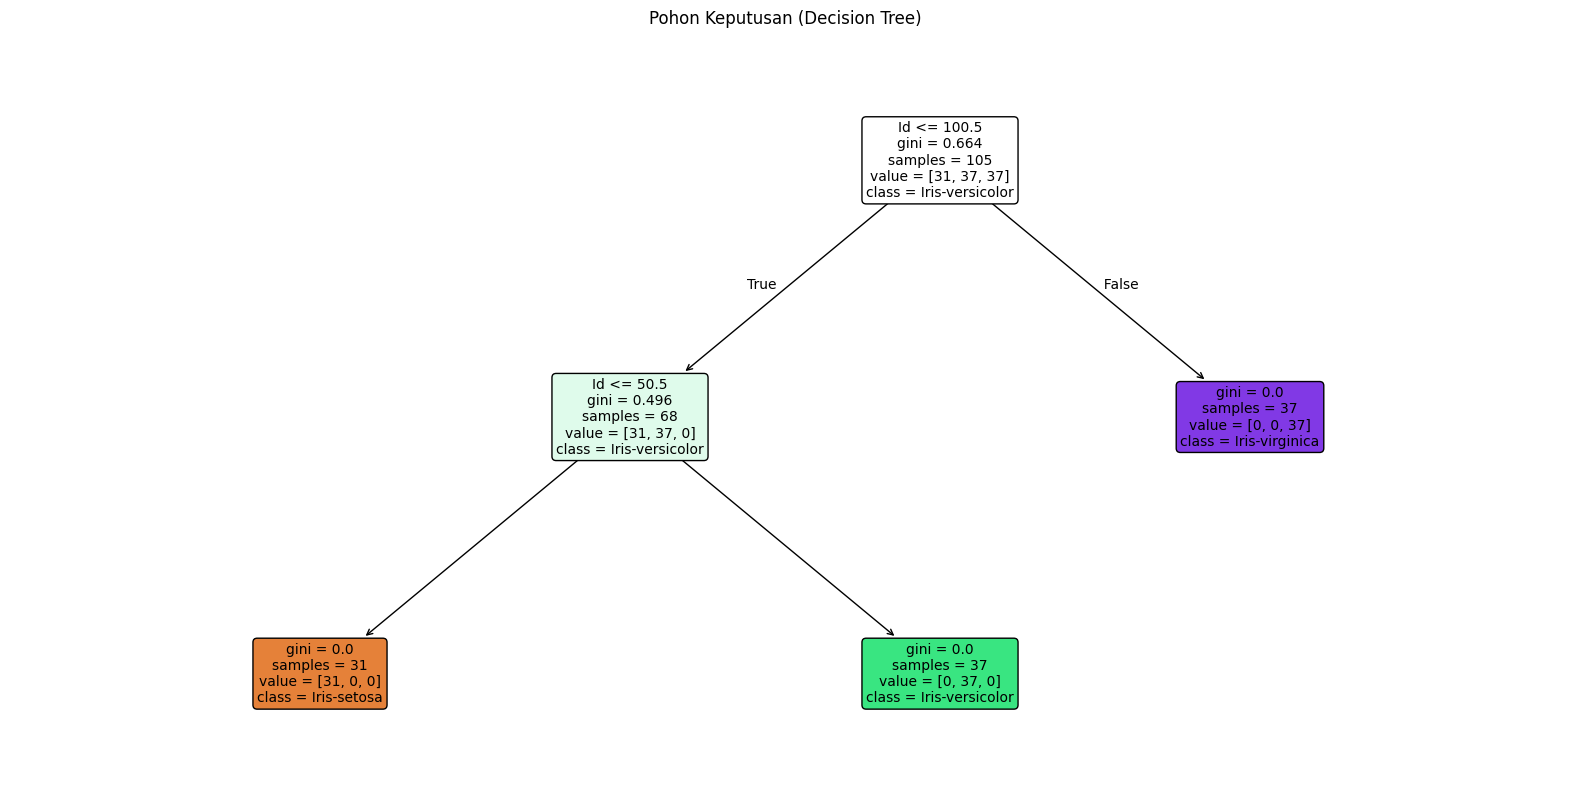

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X.columns.tolist(), class_names=le.classes_, rounded=True, fontsize=10)
plt.title('Pohon Keputusan (Decision Tree)')
plt.show()

## Klasifikasi menggunakan Random Forest
Melatih model Random Forest, membuat prediksi, dan mengevaluasi kinerjanya menggunakan Akurasi, Confusion Matrix, dan Classification Report.

Akurasi Random Forest: 1.0000

Confusion Matrix (Random Forest):


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,19,0,0
Iris-versicolor,0,13,0
Iris-virginica,0,0,13



Classification Report (Random Forest):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



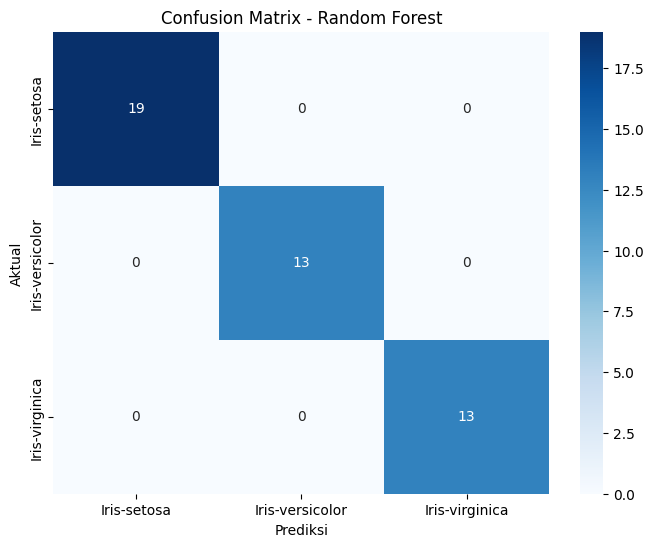

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_rfc = rfc.predict(X_test)

# Evaluasi model Random Forest
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
cr_rfc = classification_report(y_test, y_pred_rfc, target_names=le.classes_)

print(f"Akurasi Random Forest: {accuracy_rfc:.4f}")
print("\nConfusion Matrix (Random Forest):")
display(pd.DataFrame(cm_rfc, index=le.classes_, columns=le.classes_))

print("\nClassification Report (Random Forest):")
print(cr_rfc)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## Analisis dan Perbandingan Model

### 4.1. Performa Terbaik dan Perbandingan Akurasi

Pada kasus ini, baik Decision Tree maupun Random Forest sama-sama mencapai akurasi 1.0000 pada data uji. Ini menunjukkan bahwa kedua model mampu mengklasifikasikan spesies Iris dengan sangat baik di dataset yang diberikan, kemungkinan karena sifat dataset Iris yang relatif mudah dipisahkan secara linear.

In [ ]:
print(f"Akurasi Decision Tree: {accuracy_dtc:.4f}")
print(f"Akurasi Random Forest: {accuracy_rfc:.4f}")

Akurasi Decision Tree: 1.0000
Akurasi Random Forest: 1.0000


### Kelebihan dan Kekurangan Decision Tree dan Random Forest

Decision Tree tidak memerlukan normalisasi data, dan kecepatan komputasi, namun rentan terhadap overfitting, kurang robust, dan cenderung memiliki bias tinggi. Sebaliknya, Random Forest unggul dalam mengurangi overfitting, memberikan akurasi yang lebih tinggi, lebih robust terhadap noise, serta efektif menangani data berdimensi tinggi dan menyediakan informasi pentingnya fitur; meskipun demikian, model ini lebih sulit diinterpretasikan, memerlukan waktu pelatihan yang lebih lama, dan membutuhkan sumber daya komputasi yang lebih besar.

### Indikasi Overfitting pada Decision Tree

Akurasi Decision Tree pada data uji mencapai 1.0000 bisa jadi tanda overfitting, yaitu model terlalu menyesuaikan diri dengan data latih. Meski dataset Iris memang sederhana, hasil sempurna tetap perlu diwaspadai karena model mungkin kurang baik saat digunakan pada data baru.

### Pengaruh Fitur terhadap Hasil Klasifikasi

Fitur-fitur dalam dataset Iris (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) sangat memengaruhi hasil klasifikasi, di mana `feature_importances_` dari model Random Forest dapat menunjukkan fitur mana yang paling penting.

Pentingnya Fitur:


,Feature,Importance
0,Id,0.400563
4,PetalWidthCm,0.287264
3,PetalLengthCm,0.253775
1,SepalLengthCm,0.042792
2,SepalWidthCm,0.015605


/tmp/ipykernel_6414/454968825.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


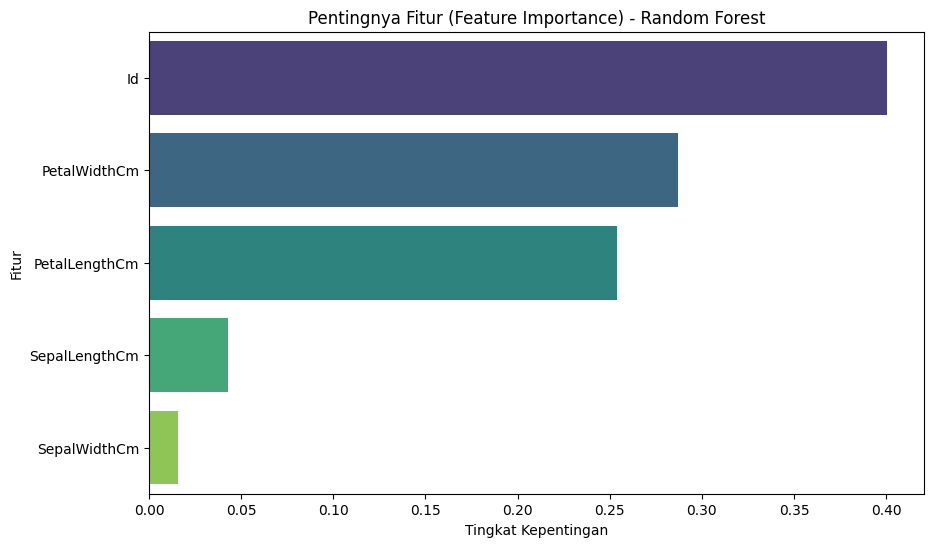

In [ ]:
feature_importances = rfc.feature_importances_

# Buat DataFrame untuk visualisasi
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

print("Pentingnya Fitur:")
display(feature_df)

# Visualisasi pentingnya fitur
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Pentingnya Fitur (Feature Importance) - Random Forest')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.show()

Dari visualisasi di atas, terlihat bahwa `PetalLengthCm` dan `PetalWidthCm` adalah fitur yang paling penting dalam mengklasifikasikan spesies bunga Iris. Ini konsisten dengan pengetahuan botani bahwa dimensi kelopak (petal) seringkali merupakan pembeda utama antara spesies Iris.

### Pengaruh `n_estimators` pada Random Forest

Parameter `n_estimators` dalam Random Forest mengontrol jumlah pohon keputusan individual yang dibangun dalam hutan. Peningkatan `n_estimators` umumnya meningkatkan stabilitas, mengurangi variansi dan overfitting, serta seringkali meningkatkan akurasi hingga titik saturasi. Namun, hal ini juga akan meningkatkan waktu komputasi dan penggunaan memori, sehingga penting untuk menyeimbangkan performa dengan efisiensi komputasi.